# Introduction
This benchmark aims to compare 3 well-known cryptographic libraries: **Bouncy Castle**, **Node's Crypto module** and **OpenSSL**. The cryptographic algorithms I have chosen to test using the given libraries were the following 3 famous algorithms: RSA, SHA-256 and ChaCha20-Poly1305.

For the OpenSSL algorithms I have used [EVP functions](https://wiki.openssl.org/index.php/EVP) which provide a higher-level API to OpenSSL. 

The goal of this benchmark isn't to compare the algorithms to each other (for example trying to decide whether ChaCha20 or RSA can encrypt a message faster), but rather comparing the libraries to each other and seeing which library can achieve a faster runtime for the chosen algorithms in the given programming language.

# Methodology
For the encryption algorithms (ChaCha20-Poly1305 and RSA) I both measured the encryption and decryption speed of a message.

In the tests I have taken a few notable measures in order to achieve more comparable results. The Java and TypeScript benchmarks were preceded by 20 warmup iterations. However, in the Google Benchmark framework I could not find a warmup iteration parameter so I ended up using a fixed 1 second long warmup period. During the benchmarks each algorithm and library pair combination had its speed measured for 10 iterations. The below numbers in the graphs are the statistical mean (average) values of those 10 iterations.

The benchmarks were configured to exclude unnecessary overhead, such as setup of the libraries, ensuring the measurements reflected only the execution time of the core cryptographic functions.

## Benchmarking frameworks
For testing the runtime of each algorithm I have used a third-party benchmark library:

- TypeScript: [tinybench](https://github.com/tinylibs/tinybench)
- Java: [Java Microbenchmark Harness](https://github.com/openjdk/jmh)
- C++: [Google Benchmark](https://github.com/google/benchmark)

## Compilers and language versions

- TypeScript: The tests were run on TypeScript version 6.0.2 using tsx 4.21.0.
- Java: The Java sources were compiled and run with Oracle OpenJDK 23.0.1.
- C++: The C++ source codes were compiled with Clang 22.1.2 using `-O3` optimization. For building the project I have setup a CMake project and used C++20.


## Hardware and Operating system
The benchmarks were run on a M3 Macbook Air with macOS 26.2.

# Results

## SHA-256

SHA-256 is a cryptographic hash function from the SHA-2 family that generates a unique, fixed-size 256-bit signature to ensure data integrity and detect unauthorized modifications.

Parameters:

- Data size: 1024 bytes
- Digest size: 32 bytes

In the SHA-256 algorithm the data size corresponds to the input data of the hash function, and the digest size corresponds to the output size of the hash function.


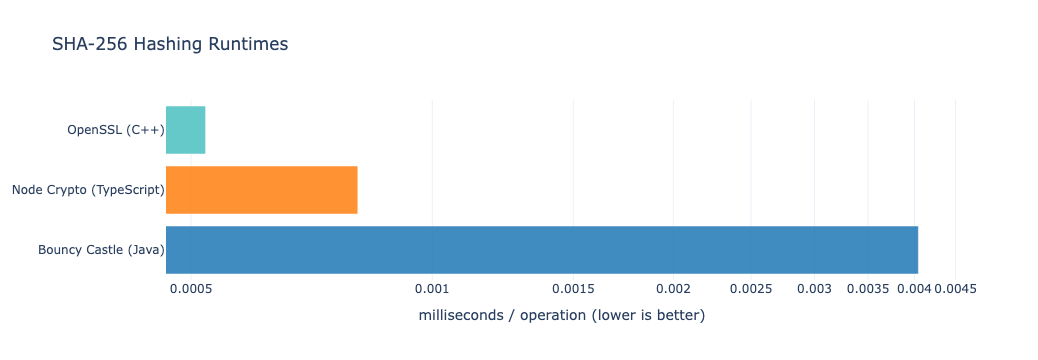

In [4]:
#| echo: false

import json
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

def load_json(path):
    with open(path, 'r') as f: return json.load(f)

# java: primaryMetric.score is nanoseconds / operation -> we calculate scoreNs / 1e9 (then * 1000 for ms)
java_results = load_json('./bouncycastle-benchmark/results.json')
java_sha = [entry['primaryMetric']['score'] / 1e6 for entry in java_results 
            if 'sha256' in entry['benchmark'].lower()][0]

# node: latency.mean is ms
node_sha_results = load_json('./node-benchmarks/results/sha256-report.json')
node_sha = node_sha_results['tasks'][0]['latency']['mean']

# cpp: real_time is in nanoseconds
cpp_results = load_json('./openssl-cpp-benchmark/results.json')
cpp_sha = [b['real_time'] / 1e6 for b in cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'sha256' in b['name'].lower()][0]

fig = go.Figure()

fig.add_trace(go.Bar(
    y=['Bouncy Castle (Java)', 'Node Crypto (TypeScript)', 'OpenSSL (C++)'],
    x=[java_sha, node_sha, cpp_sha],
    orientation='h',
    marker_color=['rgba(31, 119, 180, 0.85)', 'rgba(255, 127, 14, 0.85)', 'rgba(75, 192, 192, 0.85)'],
    hovertemplate='<b>%{y}</b><br>Latency: %{x:.6f} ms<extra></extra>'
))

fig.update_layout(
    title='SHA-256 Hashing Runtimes',
    xaxis_type="log",
    template='plotly_white',
    autosize=True,
    xaxis_title='milliseconds / operation (lower is better)',
)

fig.show()

# ChaCha20-Poly1305

ChaCha20-Poly1305 is a symmetric key streaming cipher. It uses the Poly-1305 message authentication algorithm in order to generate a MAC (Message Authentication Code) for the cipher texts so if an eavesdropper were to change the encrypted message, it would be detectable by the source.

Parameters:

- Data size: 1024 bytes
- Key size: 32 bytes

The ChaCha-Poly1305 cryptographic algorithm uses a fixed 32 bytes sized key set by the standard.

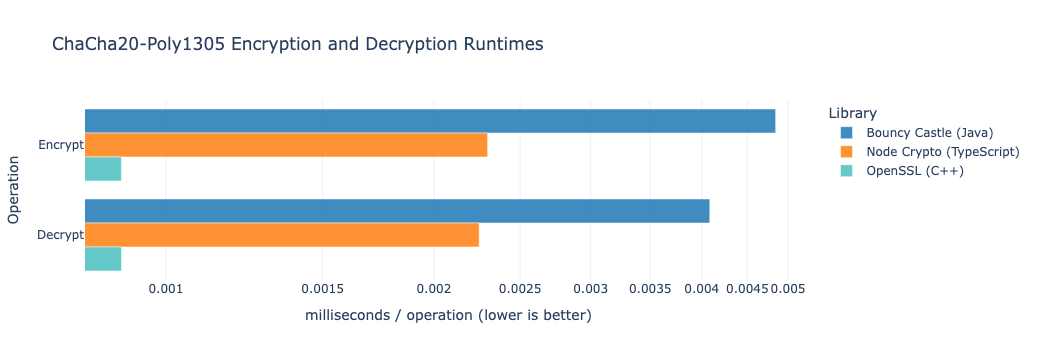

In [4]:
#| echo: false

import json
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

def load_json(path):
    with open(path, 'r') as f: return json.load(f)

java_results = load_json('./bouncycastle-benchmark/results.json')
node_chacha_results = load_json('./node-benchmarks/results/chacha20-benchmark-results.json')
cpp_results = load_json('./openssl-cpp-benchmark/results.json')

java_enc = [e['primaryMetric']['score'] / 1e6 for e in java_results if 'chacha' in e['benchmark'].lower() and 'encrypt' in e['benchmark'].lower()][0]
java_dec = [e['primaryMetric']['score'] / 1e6 for e in java_results if 'chacha' in e['benchmark'].lower() and 'decrypt' in e['benchmark'].lower()][0]

node_enc = node_chacha_results['tasks'][0]['latency']['mean']
node_dec = node_chacha_results['tasks'][1]['latency']['mean']

cpp_enc = [b['real_time'] / 1e6 for b in cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'chacha20' in b['name'].lower() and 'encrypt' in b['name'].lower()][0]
cpp_dec = [b['real_time'] / 1e6 for b in cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'chacha20' in b['name'].lower() and 'decrypt' in b['name'].lower()][0]

operations = ['Encrypt', 'Decrypt']
colors = {
    'java': 'rgba(31, 119, 180, 0.85)',
    'node': 'rgba(255, 127, 14, 0.85)',
    'cpp': 'rgba(75, 192, 192, 0.85)'
}

fig = go.Figure()

fig.add_trace(go.Bar(
    y=operations,
    x=[java_enc, java_dec],
    name='Bouncy Castle (Java)',
    orientation='h',
    marker_color=colors['java'],
    hovertemplate='<b>Bouncy Castle (Java)</b><br>%{y}: %{x:.6f} ms<extra></extra>'
))

fig.add_trace(go.Bar(
    y=operations,
    x=[node_enc, node_dec],
    name='Node Crypto (TypeScript)',
    orientation='h',
    marker_color=colors['node'],
    hovertemplate='<b>Node Crypto (TypeScript)</b><br>%{y}: %{x:.6f} ms<extra></extra>'
))

fig.add_trace(go.Bar(
    y=operations,
    x=[cpp_enc, cpp_dec],
    name='OpenSSL (C++)',
    orientation='h',
    marker_color=colors['cpp'],
    hovertemplate='<b>OpenSSL (C++)</b><br>%{y}: %{x:.6f} ms<extra></extra>'
))

fig.update_layout(
    title='ChaCha20-Poly1305 Encryption and Decryption Runtimes',
    xaxis_title='milliseconds / operation (lower is better)',
    xaxis_type="log",
    yaxis_title="Operation",
    barmode='group',
    template='plotly_white',
    legend_title="Library",
    autosize=True,
    yaxis=dict(autorange="reversed")
)

fig.show()

# RSA

RSA is an asymmetric cryptographic algorithm that relies on the mathematical difficulty of factoring large prime numbers to provide secure data encryption.

Parameters:

- Data size: 32 bytes
- Key size: 2048 bits

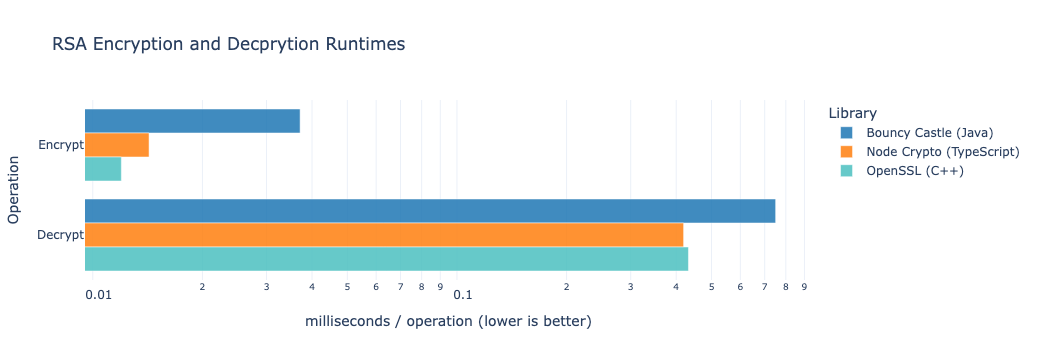

In [3]:
#| echo: false

import json
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

def load_json(path):
    with open(path, 'r') as f: return json.load(f)

java_results = load_json('./bouncycastle-benchmark/results.json')
node_rsa_results = load_json('./node-benchmarks/results/rsa-benchmark-results.json')
cpp_results = load_json('./openssl-cpp-benchmark/results.json')

java_enc = [e['primaryMetric']['score'] / 1e6 for e in java_results if 'rsa' in e['benchmark'].lower() and 'encrypt' in e['benchmark'].lower()][0]
java_dec = [e['primaryMetric']['score'] / 1e6 for e in java_results if 'rsa' in e['benchmark'].lower() and 'decrypt' in e['benchmark'].lower()][0]

node_enc = node_rsa_results['tasks'][0]['latency']['mean']
node_dec = node_rsa_results['tasks'][1]['latency']['mean']

cpp_enc = [b['real_time'] / 1e6 for b in cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'rsa' in b['name'].lower() and 'encrypt' in b['name'].lower()][0]
cpp_dec = [b['real_time'] / 1e6 for b in cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'rsa' in b['name'].lower() and 'decrypt' in b['name'].lower()][0]

operations = ['Encrypt', 'Decrypt']
colors = {
    'java': 'rgba(31, 119, 180, 0.85)',
    'node': 'rgba(255, 127, 14, 0.85)',
    'cpp': 'rgba(75, 192, 192, 0.85)'
}

fig = go.Figure()

fig.add_trace(go.Bar(
    y=operations,
    x=[java_enc, java_dec],
    name='Bouncy Castle (Java)',
    orientation='h',
    marker_color=colors['java'],
    hovertemplate='<b>Bouncy Castle (Java)</b><br>%{y}: %{x:.4f} ms<extra></extra>'
))

fig.add_trace(go.Bar(
    y=operations,
    x=[node_enc, node_dec],
    name='Node Crypto (TypeScript)',
    orientation='h',
    marker_color=colors['node'],
    hovertemplate='<b>Node Crypto (TypeScript)</b><br>%{y}: %{x:.4f} ms<extra></extra>'
))

fig.add_trace(go.Bar(
    y=operations,
    x=[cpp_enc, cpp_dec],
    name='OpenSSL (C++)',
    orientation='h',
    marker_color=colors['cpp'],
    hovertemplate='<b>OpenSSL (C++)</b><br>%{y}: %{x:.4f} ms<extra></extra>'
))

fig.update_layout(
    title='RSA Encryption and Decprytion Runtimes',
    xaxis_title='milliseconds / operation (lower is better)',
    xaxis_type="log",
    yaxis_title="Operation",
    barmode='group',
    template='plotly_white',
    legend_title="Library",
    autosize=True,
    yaxis=dict(autorange="reversed")
)

fig.show()

As we can see the RSA decryption process produces much slower run times than the encryption process. This is a well-known property of the RSA algorithm. Further information about this can be found here: [https://security.stackexchange.com/questions/57205/why-is-rsa-decryption-slow](https://security.stackexchange.com/questions/57205/why-is-rsa-decryption-slow).

# Naive implementation of ChaCha20-Poly1305

In the scope of this project I have also compared a naive implementation of ChaCha20-Poly1305 written in C++ to the other 3 cryptographic libraries.


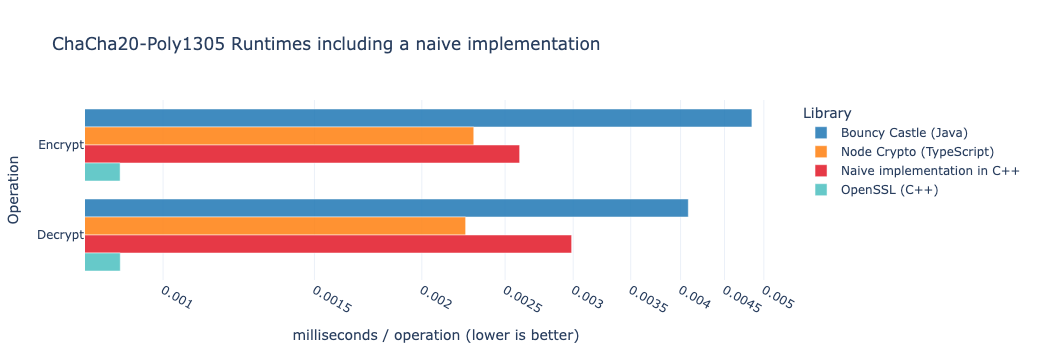

In [5]:
#| echo: false

import json
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

def load_json(path):
    with open(path, 'r') as f: return json.load(f)

java_results = load_json('./bouncycastle-benchmark/results.json')
node_chacha_results = load_json('./node-benchmarks/results/chacha20-benchmark-results.json')
cpp_results = load_json('./openssl-cpp-benchmark/results.json')
naive_cpp_results = load_json('./chacha-naive-cpp/results.json')

java_enc = [e['primaryMetric']['score'] / 1e6 for e in java_results if 'chacha' in e['benchmark'].lower() and 'encrypt' in e['benchmark'].lower()][0]
java_dec = [e['primaryMetric']['score'] / 1e6 for e in java_results if 'chacha' in e['benchmark'].lower() and 'decrypt' in e['benchmark'].lower()][0]

node_enc = node_chacha_results['tasks'][0]['latency']['mean']
node_dec = node_chacha_results['tasks'][1]['latency']['mean']

cpp_enc = [b['real_time'] / 1e6 for b in cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'chacha20' in b['name'].lower() and 'encrypt' in b['name'].lower()][0]
cpp_dec = [b['real_time'] / 1e6 for b in cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'chacha20' in b['name'].lower() and 'decrypt' in b['name'].lower()][0]

naive_cpp_enc = [b['real_time'] / 1e6 for b in naive_cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'chacha20' in b['name'].lower() and 'encrypt' in b['name'].lower()][0]
naive_cpp_dec = [b['real_time'] / 1e6 for b in naive_cpp_results['benchmarks'] 
           if b.get('run_type') == 'aggregate' and b.get('aggregate_name') == 'mean' 
           and 'chacha20' in b['name'].lower() and 'decrypt' in b['name'].lower()][0]

operations = ['Encrypt', 'Decrypt']
colors = {
    'java': 'rgba(31, 119, 180, 0.85)',
    'node': 'rgba(255, 127, 14, 0.85)',
    'cpp': 'rgba(75, 192, 192, 0.85)',
    'naive_cpp': 'rgba(230, 57, 70, 1)'
}

fig = go.Figure()

fig.add_trace(go.Bar(
    y=operations,
    x=[java_enc, java_dec],
    name='Bouncy Castle (Java)',
    orientation='h',
    marker_color=colors['java'],
    hovertemplate='<b>Bouncy Castle (Java)</b><br>%{y}: %{x:.6f} ms<extra></extra>'
))

fig.add_trace(go.Bar(
    y=operations,
    x=[node_enc, node_dec],
    name='Node Crypto (TypeScript)',
    orientation='h',
    marker_color=colors['node'],
    hovertemplate='<b>Node Crypto (TypeScript)</b><br>%{y}: %{x:.6f} ms<extra></extra>'
))

fig.add_trace(go.Bar(
    y=operations,
    x=[naive_cpp_enc, naive_cpp_dec],
    name='Naive implementation in C++',
    orientation='h',
    marker_color=colors['naive_cpp'],
    hovertemplate='<b>Naive C++</b><br>%{y}: %{x:.6f} ms<extra></extra>'
))

fig.add_trace(go.Bar(
    y=operations,
    x=[cpp_enc, cpp_dec],
    name='OpenSSL (C++)',
    orientation='h',
    marker_color=colors['cpp'],
    hovertemplate='<b>OpenSSL (C++)</b><br>%{y}: %{x:.6f} ms<extra></extra>'
))

fig.update_layout(
    title='ChaCha20-Poly1305 Runtimes including a naive implementation',
    xaxis_title='milliseconds / operation (lower is better)',
    xaxis_type="log",
    yaxis_title="Operation",
    barmode='group',
    template='plotly_white',
    legend_title="Library",
    autosize=True,
    yaxis=dict(autorange="reversed")
)

fig.show()

As we can see the naive C++ implementation managed to only outperform the BouncyCastle benchmark.

To make sure this implementation of the algorithm was right, I have compared a few sample outputs with what OpenSSL gives us. The results matched with each other.


# Conclusion

In my measurements I have witnessed that OpenSSL managed to outperform, or at least tie the other libraries in every algorithm, as expected. However, contrary to my expectation Node's crypto module managed to outperform Java's Bouncy Castle library.

After finding out the results above, I have done some research into the underlying implementation of the given libraries.
Node's crypto module seems to be actually calling OpenSSL under the hood. The difference that we see between the OpenSSL results and the Node results could be attributed to the call overhead that Node has in order to reach the underlying OpenSSL implementation.

For example here is the RSA algorithm implementation from the Node's source code: [https://github.com/nodejs/node/blob/main/src/crypto/crypto_rsa.cc](https://github.com/nodejs/node/blob/main/src/crypto/crypto_rsa.cc).

Looking into Bouncy Castle I have discovered that it is implemented purely in Java.
Here is the SHA-256 implementation inside Bouncy Castle's library: [https://github.com/bcgit/bc-java/blob/main/core/src/main/java/org/bouncycastle/crypto/digests/SHA256Digest.java](https://github.com/bcgit/bc-java/blob/main/core/src/main/java/org/bouncycastle/crypto/digests/SHA256Digest.java).

On the other hand OpenSSL is written in C and assembly, utilizing platform specific CPU instructions. For example here is the file for SHA-256 in OpenSSL: [https://github.com/openssl/openssl/blob/master/crypto/sha/asm/sha256-mb-x86_64.pl](https://github.com/openssl/openssl/blob/master/crypto/sha/asm/sha256-mb-x86_64.pl). This file is specifically for the X86 CPU architecture. The file is written in Perl and calls the X86 specific CPU instructions, for example `sha256rnds2` which performs 2 rounds from SHA-256. 

---


# Source code

The source code for all of the benchmarks and this webpage can be found in the following Github repository: [https://github.com/nagyb3/perfopt-homework](https://github.com/nagyb3/perfopt-homework).


# AI disclosure and experiences

During the creation of the benchmarks I have used Github Copilot's inline suggestion for speeding up the coding process but have manually reviewed every change in order to make results accurate.

For creating the naive implementation of ChaCha20-Poly1305 I have utilized Github Copilot's agent mode. At first the agent wasn't able to give me a correct algorithm and took quite some time to debug and fix the implementation.

For creating the visualizations using plotly, I have utilized Gemini 2.5 Flash. This model didn't give me good enough graphs on the first try, so most of the time these generations were only good as a skeleton of the final version.
